In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/manufacturing_dataset_1000_samples.csv")

In [3]:
df.head()

,Timestamp,Injection_Temperature,Injection_Pressure,Cycle_Time,Cooling_Time,Material_Viscosity,Ambient_Temperature,Machine_Age,Operator_Experience,Maintenance_Hours,Shift,Machine_Type,Material_Grade,Day_of_Week,Temperature_Pressure_Ratio,Total_Cycle_Time,Efficiency_Score,Machine_Utilization,Parts_Per_Hour
0,01-01-2023 00:00,221.0,136.0,28.7,13.6,375.5,28.0,3.8,11.2,64,Evening,Type_B,Economy,Thursday,1.625,42.3,0.063,0.510,36.5
1,01-01-2023 01:00,213.3,128.9,34.5,14.0,215.8,22.6,6.8,6.3,58,Night,Type_A,Standard,Wednesday,1.655,48.5,0.037,0.389,29.9
2,01-01-2023 02:00,222.8,115.9,19.9,9.5,307.0,25.3,4.2,9.6,47,Day,Type_A,Standard,Monday,1.922,29.4,0.061,0.551,56.9
3,01-01-2023 03:00,233.3,105.3,39.2,13.1,137.8,26.0,9.2,8.6,49,Evening,Type_A,Premium,Saturday,2.215,52.3,0.054,0.293,31.0
4,01-01-2023 04:00,212.2,125.5,45.0,9.9,298.2,23.6,6.2,23.0,49,Night,Type_B,Premium,Monday,1.691,54.9,0.145,0.443,15.0


In [4]:
df.shape

(1000, 19)

In [5]:
df.columns

Index(['Timestamp', 'Injection_Temperature', 'Injection_Pressure',
       'Cycle_Time', 'Cooling_Time', 'Material_Viscosity',
       'Ambient_Temperature', 'Machine_Age', 'Operator_Experience',
       'Maintenance_Hours', 'Shift', 'Machine_Type', 'Material_Grade',
       'Day_of_Week', 'Temperature_Pressure_Ratio', 'Total_Cycle_Time',
       'Efficiency_Score', 'Machine_Utilization', 'Parts_Per_Hour'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Timestamp                   1000 non-null   object 
 1   Injection_Temperature       1000 non-null   float64
 2   Injection_Pressure          1000 non-null   float64
 3   Cycle_Time                  1000 non-null   float64
 4   Cooling_Time                1000 non-null   float64
 5   Material_Viscosity          980 non-null    float64
 6   Ambient_Temperature         980 non-null    float64
 7   Machine_Age                 1000 non-null   float64
 8   Operator_Experience         980 non-null    float64
 9   Maintenance_Hours           1000 non-null   int64  
 10  Shift                       1000 non-null   object 
 11  Machine_Type                1000 non-null   object 
 12  Material_Grade              1000 non-null   object 
 13  Day_of_Week                 1000 n

In [7]:
df.isnull().sum()

Timestamp                      0
Injection_Temperature          0
Injection_Pressure             0
Cycle_Time                     0
Cooling_Time                   0
Material_Viscosity            20
Ambient_Temperature           20
Machine_Age                    0
Operator_Experience           20
Maintenance_Hours              0
Shift                          0
Machine_Type                   0
Material_Grade                 0
Day_of_Week                    0
Temperature_Pressure_Ratio     0
Total_Cycle_Time               0
Efficiency_Score               0
Machine_Utilization            0
Parts_Per_Hour                 0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.describe()

,Injection_Temperature,Injection_Pressure,Cycle_Time,Cooling_Time,Material_Viscosity,Ambient_Temperature,Machine_Age,Operator_Experience,Maintenance_Hours,Temperature_Pressure_Ratio,Total_Cycle_Time,Efficiency_Score,Machine_Utilization,Parts_Per_Hour
count,1000.000000,1000.000000,1000.00000,1000.00000,980.000000,980.000000,1000.000000,980.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,215.315900,116.075000,35.85170,11.92320,251.630714,22.941224,7.855900,30.795204,50.580000,1.885852,47.737000,0.192688,0.356844,29.298100
std,11.995507,14.667246,8.35349,2.30429,73.348695,2.773712,3.900798,27.684769,16.014558,0.274323,8.671153,0.173839,0.195610,11.955497
min,180.000000,80.000000,16.30000,8.00000,104.600000,18.000000,1.000000,1.000000,26.000000,1.286000,24.600000,0.006000,0.001000,5.000000
25%,207.200000,105.900000,28.80000,10.27500,200.900000,20.800000,4.700000,9.800000,45.000000,1.683750,41.000000,0.061000,0.193000,17.500000
50%,215.300000,115.950000,36.85000,11.90000,242.700000,22.900000,7.900000,22.100000,50.000000,1.849500,48.550000,0.139000,0.355500,28.200000
75%,222.800000,125.925000,45.00000,13.50000,295.300000,25.100000,11.100000,43.425000,55.000000,2.044250,55.300000,0.274000,0.520000,38.000000
max,300.000000,150.000000,60.00000,19.90000,1000.000000,28.000000,15.000000,120.000000,500.000000,2.843000,64.900000,0.840000,0.755000,68.600000


In [11]:
df["Parts_Per_Hour"].describe()

count    1000.000000
mean       29.298100
std        11.955497
min         5.000000
25%        17.500000
50%        28.200000
75%        38.000000
max        68.600000
Name: Parts_Per_Hour, dtype: float64

In [12]:
print("Mean Parts Per Hour:", df["Parts_Per_Hour"].mean())
print("Median Parts Per Hour:", df["Parts_Per_Hour"].median())

Mean Parts Per Hour: 29.2981
Median Parts Per Hour: 28.2


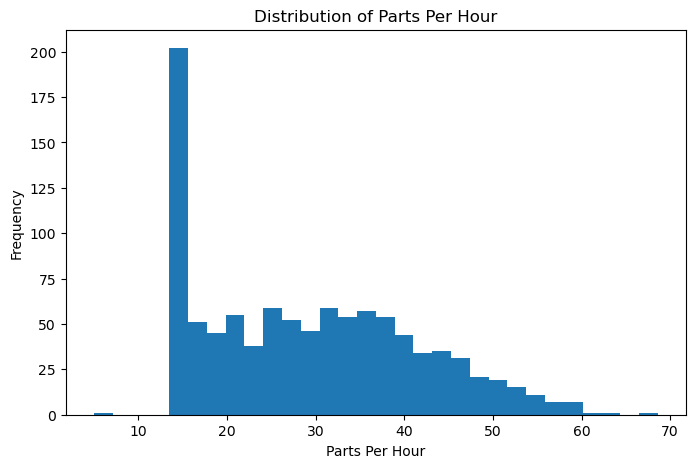

In [13]:
plt.figure(figsize=(8, 5))

plt.hist(df["Parts_Per_Hour"], bins=30)

plt.xlabel("Parts Per Hour")
plt.ylabel("Frequency")
plt.title("Distribution of Parts Per Hour")

plt.show()

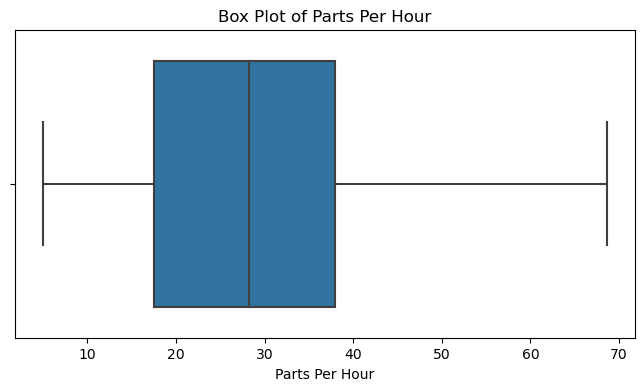

In [14]:
plt.figure(figsize=(8, 4))

sns.boxplot(x=df["Parts_Per_Hour"])

plt.xlabel("Parts Per Hour")
plt.title("Box Plot of Parts Per Hour")

plt.show()

In [15]:
print("Missing Parts_Per_Hour:", df["Parts_Per_Hour"].isnull().sum())

Missing Parts_Per_Hour: 0


In [16]:
numerical_columns = df.select_dtypes(include=np.number).columns

print("Numerical columns:")
print(numerical_columns.tolist())

Numerical columns:
['Injection_Temperature', 'Injection_Pressure', 'Cycle_Time', 'Cooling_Time', 'Material_Viscosity', 'Ambient_Temperature', 'Machine_Age', 'Operator_Experience', 'Maintenance_Hours', 'Temperature_Pressure_Ratio', 'Total_Cycle_Time', 'Efficiency_Score', 'Machine_Utilization', 'Parts_Per_Hour']


In [17]:
correlation = df[numerical_columns].corr()

correlation["Parts_Per_Hour"].sort_values(ascending=False)

Parts_Per_Hour                1.000000
Operator_Experience           0.300891
Efficiency_Score              0.286794
Injection_Temperature         0.184353
Machine_Utilization           0.174573
Injection_Pressure            0.160362
Ambient_Temperature           0.011812
Cooling_Time                  0.006215
Maintenance_Hours            -0.032955
Material_Viscosity           -0.080575
Temperature_Pressure_Ratio   -0.086113
Machine_Age                  -0.174518
Total_Cycle_Time             -0.792862
Cycle_Time                   -0.819446
Name: Parts_Per_Hour, dtype: float64

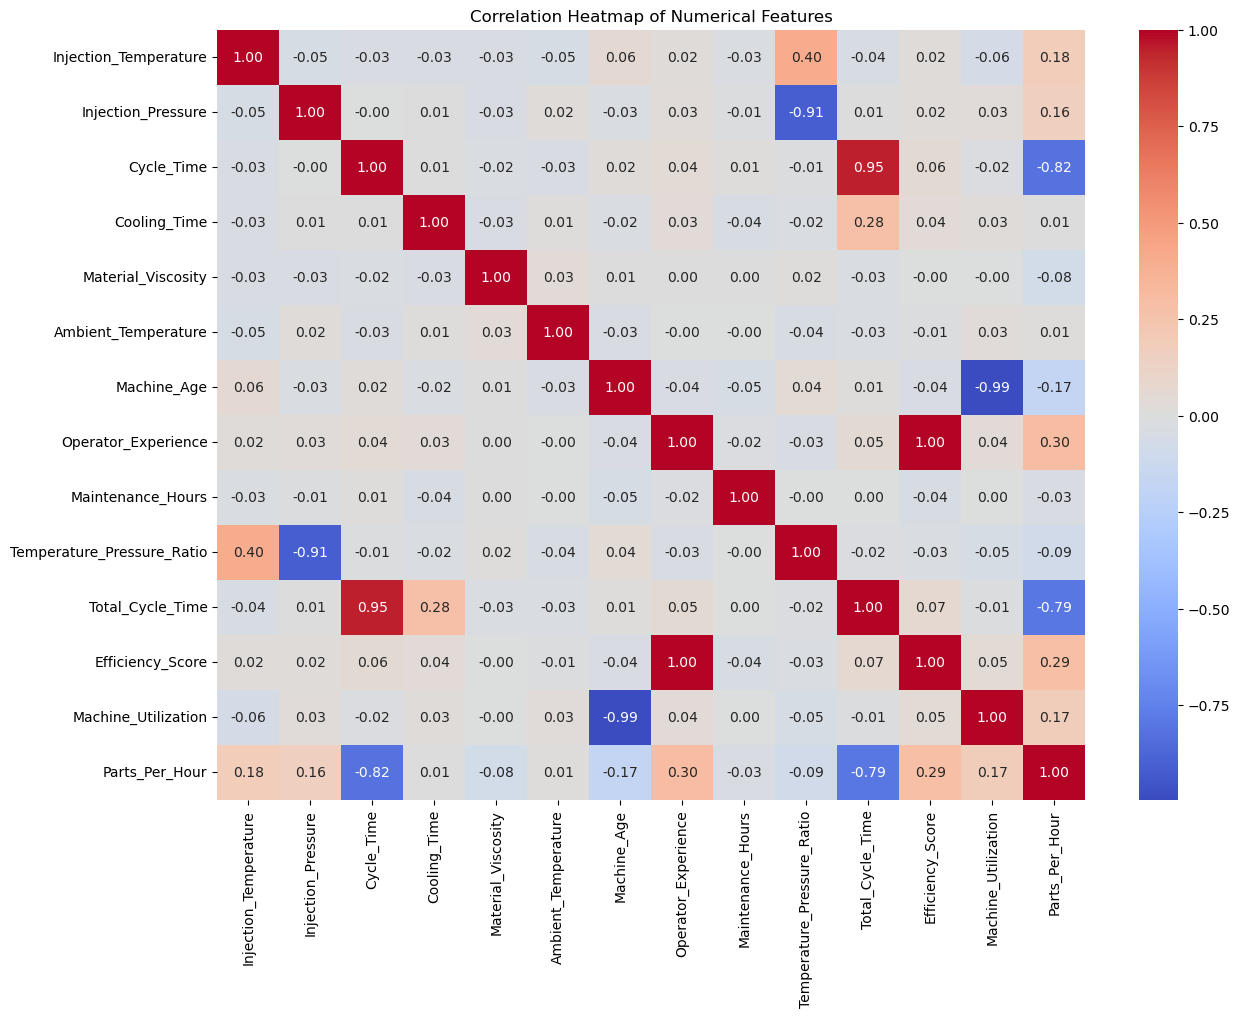

In [18]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Numerical Features")

plt.show()

In [19]:
target_correlation = correlation["Parts_Per_Hour"].sort_values(ascending=False)

target_correlation

Parts_Per_Hour                1.000000
Operator_Experience           0.300891
Efficiency_Score              0.286794
Injection_Temperature         0.184353
Machine_Utilization           0.174573
Injection_Pressure            0.160362
Ambient_Temperature           0.011812
Cooling_Time                  0.006215
Maintenance_Hours            -0.032955
Material_Viscosity           -0.080575
Temperature_Pressure_Ratio   -0.086113
Machine_Age                  -0.174518
Total_Cycle_Time             -0.792862
Cycle_Time                   -0.819446
Name: Parts_Per_Hour, dtype: float64

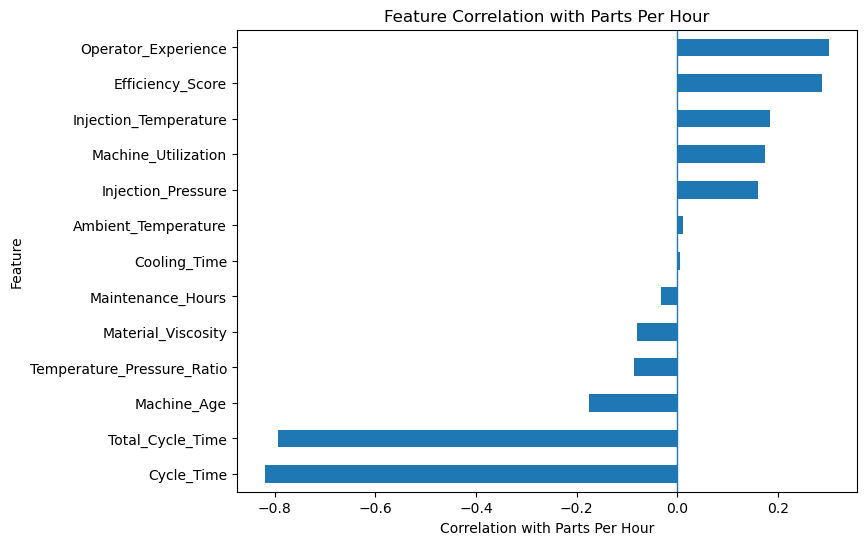

In [20]:
plt.figure(figsize=(8, 6))

target_correlation.drop("Parts_Per_Hour").sort_values().plot(kind="barh")

plt.xlabel("Correlation with Parts Per Hour")
plt.ylabel("Feature")
plt.title("Feature Correlation with Parts Per Hour")

plt.axvline(0, linewidth=1)

plt.show()

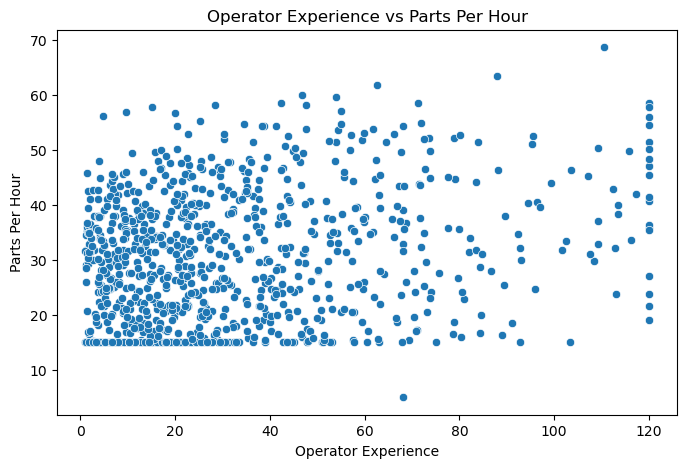

In [21]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Operator_Experience",
    y="Parts_Per_Hour"
)

plt.xlabel("Operator Experience")
plt.ylabel("Parts Per Hour")
plt.title("Operator Experience vs Parts Per Hour")

plt.show()

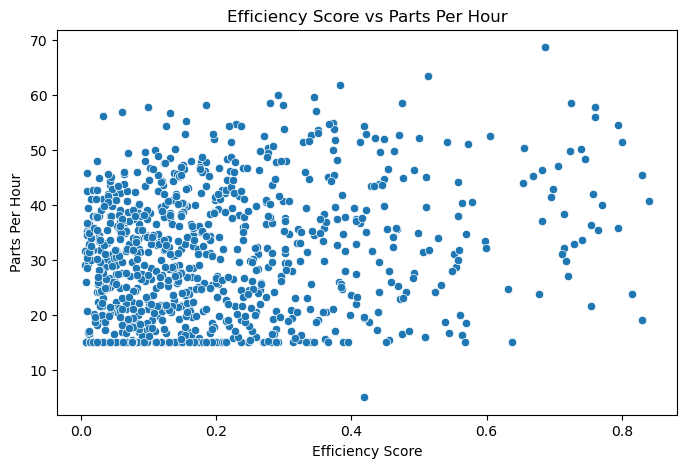

In [22]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Efficiency_Score",
    y="Parts_Per_Hour"
)

plt.xlabel("Efficiency Score")
plt.ylabel("Parts Per Hour")
plt.title("Efficiency Score vs Parts Per Hour")

plt.show()

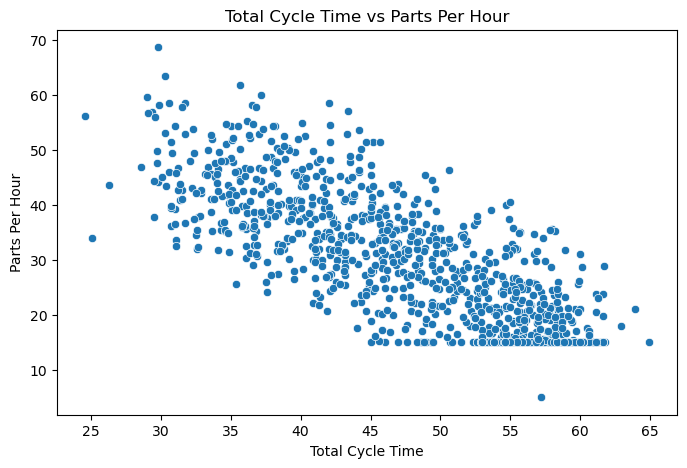

In [23]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Total_Cycle_Time",
    y="Parts_Per_Hour"
)

plt.xlabel("Total Cycle Time")
plt.ylabel("Parts Per Hour")
plt.title("Total Cycle Time vs Parts Per Hour")

plt.show()

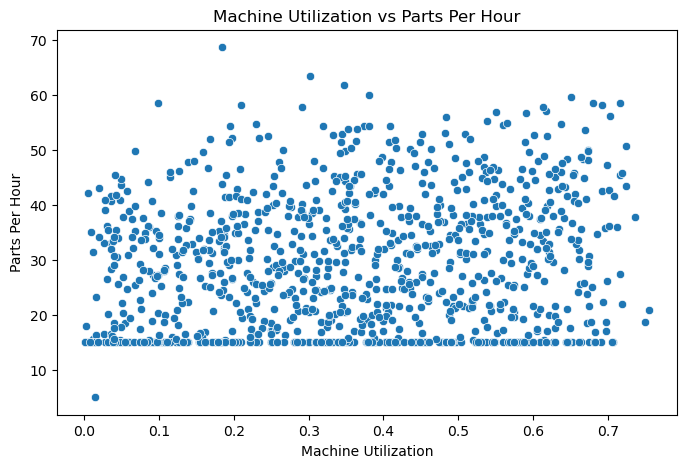

In [24]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Machine_Utilization",
    y="Parts_Per_Hour"
)

plt.xlabel("Machine Utilization")
plt.ylabel("Parts Per Hour")
plt.title("Machine Utilization vs Parts Per Hour")

plt.show()

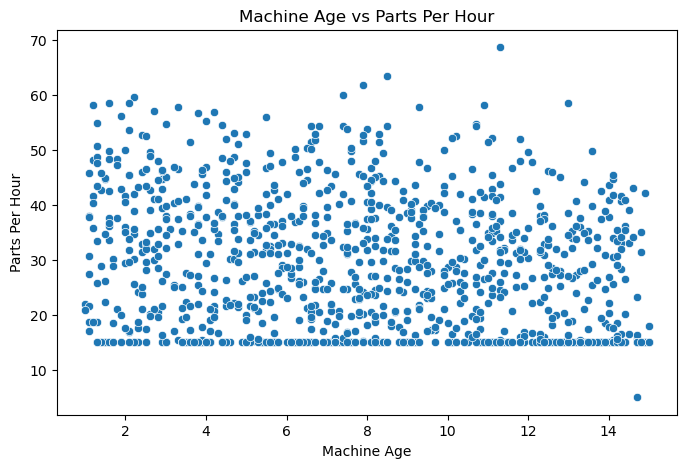

In [25]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Machine_Age",
    y="Parts_Per_Hour"
)

plt.xlabel("Machine Age")
plt.ylabel("Parts Per Hour")
plt.title("Machine Age vs Parts Per Hour")

plt.show()

In [26]:
categorical_columns = [
    "Shift",
    "Machine_Type",
    "Material_Grade",
    "Day_of_Week"
]

for column in categorical_columns:
    print(f"\n{column}:")
    print(df[column].value_counts())


Shift:
Shift
Day        517
Evening    277
Night      206
Name: count, dtype: int64

Machine_Type:
Machine_Type
Type_A    384
Type_B    347
Type_C    269
Name: count, dtype: int64

Material_Grade:
Material_Grade
Standard    591
Premium     210
Economy     199
Name: count, dtype: int64

Day_of_Week:
Day_of_Week
Friday       168
Wednesday    155
Thursday     150
Saturday     141
Tuesday      138
Monday       136
Sunday       112
Name: count, dtype: int64


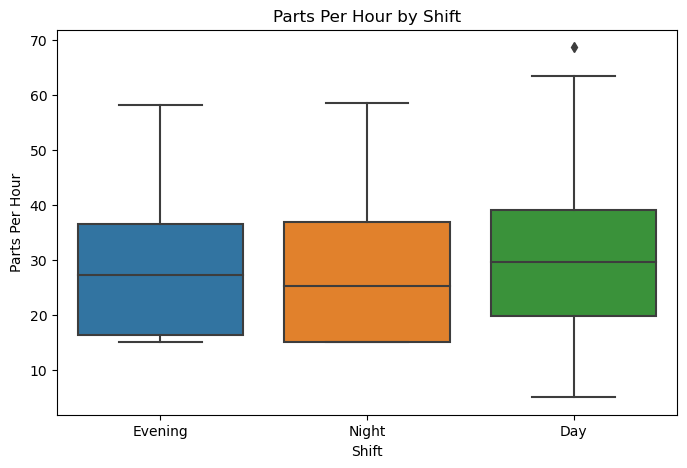

In [27]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Shift",
    y="Parts_Per_Hour"
)

plt.xlabel("Shift")
plt.ylabel("Parts Per Hour")
plt.title("Parts Per Hour by Shift")

plt.show()

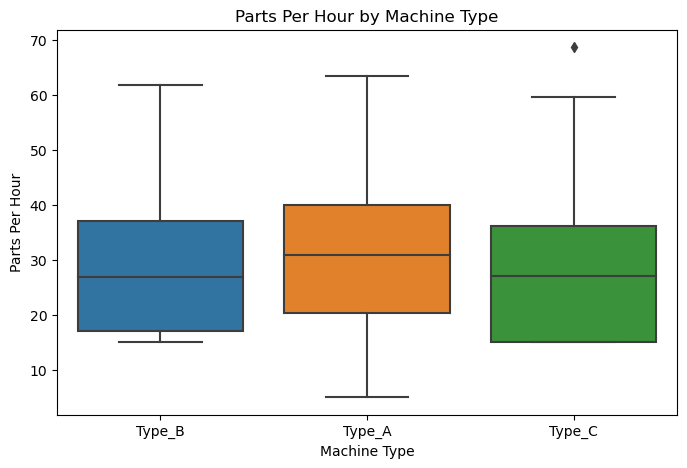

In [28]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Machine_Type",
    y="Parts_Per_Hour"
)

plt.xlabel("Machine Type")
plt.ylabel("Parts Per Hour")
plt.title("Parts Per Hour by Machine Type")

plt.show()

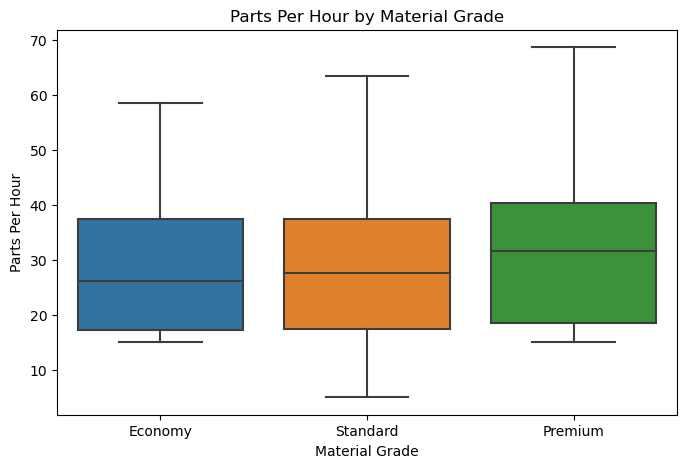

In [29]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Material_Grade",
    y="Parts_Per_Hour"
)

plt.xlabel("Material Grade")
plt.ylabel("Parts Per Hour")
plt.title("Parts Per Hour by Material Grade")

plt.show()

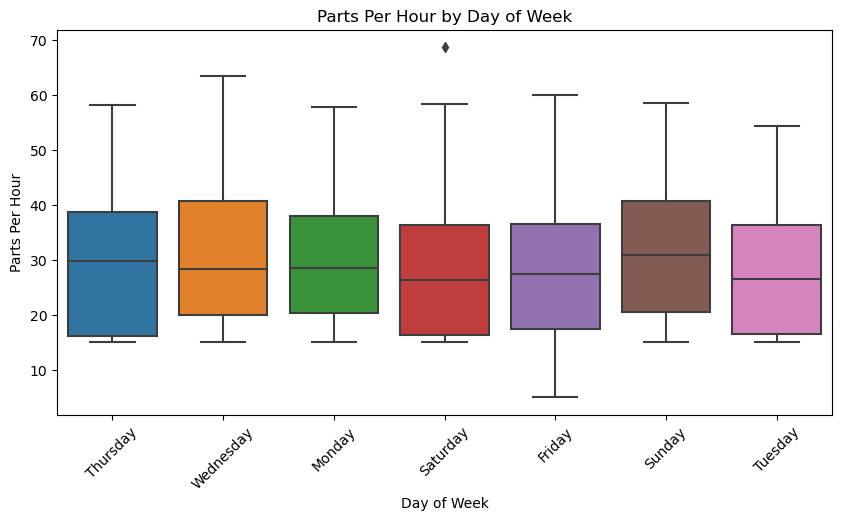

In [30]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df,
    x="Day_of_Week",
    y="Parts_Per_Hour"
)

plt.xlabel("Day of Week")
plt.ylabel("Parts Per Hour")
plt.title("Parts Per Hour by Day of Week")

plt.xticks(rotation=45)

plt.show()

In [31]:
for column in categorical_columns:
    print(f"\nAverage Parts Per Hour by {column}:")
    print(
        df.groupby(column)["Parts_Per_Hour"]
        .mean()
        .sort_values(ascending=False)
    )


Average Parts Per Hour by Shift:
Shift
Day        30.608317
Evening    28.102527
Night      27.617476
Name: Parts_Per_Hour, dtype: float64

Average Parts Per Hour by Machine_Type:
Machine_Type
Type_A    30.994010
Type_B    28.443516
Type_C    27.979554
Name: Parts_Per_Hour, dtype: float64

Average Parts Per Hour by Material_Grade:
Material_Grade
Premium     31.005238
Standard    28.924365
Economy     28.606533
Name: Parts_Per_Hour, dtype: float64

Average Parts Per Hour by Day_of_Week:
Day_of_Week
Sunday       31.046429
Wednesday    30.611613
Thursday     29.650000
Monday       29.450735
Friday       28.585119
Tuesday      28.132609
Saturday     27.934043
Name: Parts_Per_Hour, dtype: float64


In [32]:
numerical_columns = df.select_dtypes(include=np.number).columns.tolist()

print(numerical_columns)

['Injection_Temperature', 'Injection_Pressure', 'Cycle_Time', 'Cooling_Time', 'Material_Viscosity', 'Ambient_Temperature', 'Machine_Age', 'Operator_Experience', 'Maintenance_Hours', 'Temperature_Pressure_Ratio', 'Total_Cycle_Time', 'Efficiency_Score', 'Machine_Utilization', 'Parts_Per_Hour']


In [33]:
outlier_counts = {}

for column in numerical_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ][column].count()

    outlier_counts[column] = outliers

outlier_counts = pd.Series(outlier_counts).sort_values(ascending=False)

outlier_counts

Operator_Experience           44
Efficiency_Score              40
Temperature_Pressure_Ratio    17
Injection_Temperature          9
Maintenance_Hours              7
Cooling_Time                   3
Material_Viscosity             1
Injection_Pressure             0
Cycle_Time                     0
Ambient_Temperature            0
Machine_Age                    0
Total_Cycle_Time               0
Machine_Utilization            0
Parts_Per_Hour                 0
dtype: int64

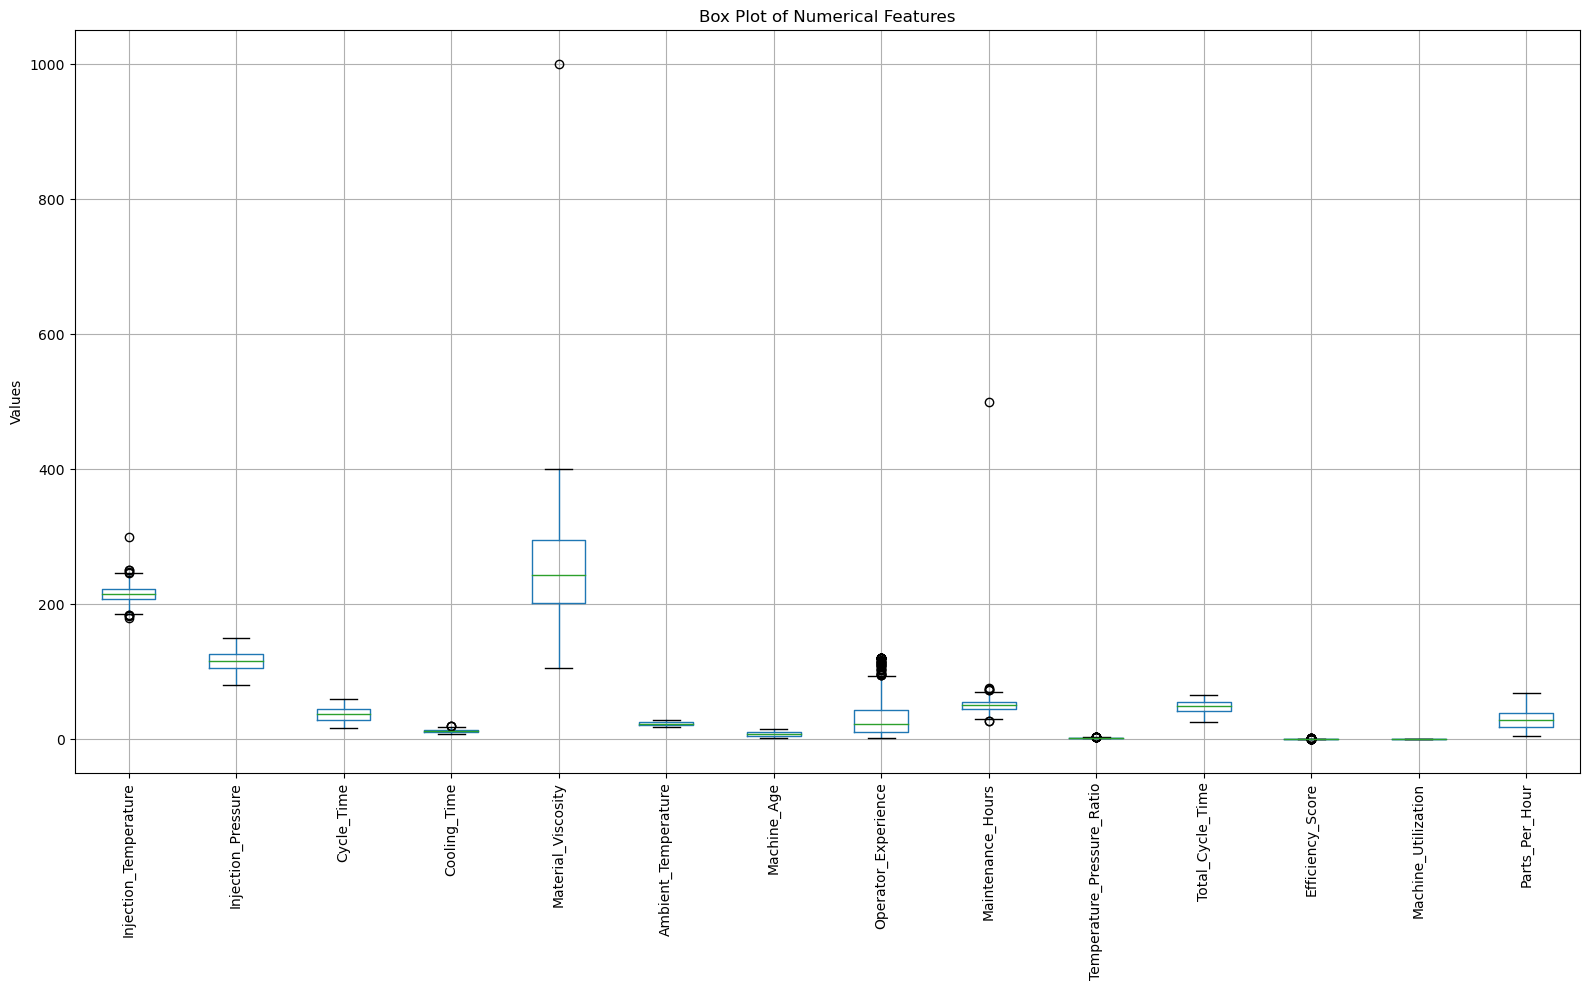

In [34]:
plt.figure(figsize=(16, 10))

df[numerical_columns].boxplot(rot=90)

plt.title("Box Plot of Numerical Features")
plt.ylabel("Values")

plt.tight_layout()
plt.show()

In [35]:
Q1 = df["Parts_Per_Hour"].quantile(0.25)
Q3 = df["Parts_Per_Hour"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

target_outliers = df[
    (df["Parts_Per_Hour"] < lower_bound) |
    (df["Parts_Per_Hour"] > upper_bound)
]

print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
print("Number of target outliers:", len(target_outliers))

Lower bound: -13.25
Upper bound: 68.75
Number of target outliers: 0


In [36]:
outlier_counts

Operator_Experience           44
Efficiency_Score              40
Temperature_Pressure_Ratio    17
Injection_Temperature          9
Maintenance_Hours              7
Cooling_Time                   3
Material_Viscosity             1
Injection_Pressure             0
Cycle_Time                     0
Ambient_Temperature            0
Machine_Age                    0
Total_Cycle_Time               0
Machine_Utilization            0
Parts_Per_Hour                 0
dtype: int64

In [37]:
engineered_features = [
    "Temperature_Pressure_Ratio",
    "Total_Cycle_Time",
    "Efficiency_Score",
    "Machine_Utilization"
]

df[engineered_features].describe()

,Temperature_Pressure_Ratio,Total_Cycle_Time,Efficiency_Score,Machine_Utilization
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,1.885852,47.737000,0.192688,0.356844
std,0.274323,8.671153,0.173839,0.195610
min,1.286000,24.600000,0.006000,0.001000
25%,1.683750,41.000000,0.061000,0.193000
50%,1.849500,48.550000,0.139000,0.355500
75%,2.044250,55.300000,0.274000,0.520000
max,2.843000,64.900000,0.840000,0.755000


In [39]:
df[engineered_features + ["Parts_Per_Hour"]].corr()["Parts_Per_Hour"].sort_values(ascending=False)

Parts_Per_Hour                1.000000
Efficiency_Score              0.286794
Machine_Utilization           0.174573
Temperature_Pressure_Ratio   -0.086113
Total_Cycle_Time             -0.792862
Name: Parts_Per_Hour, dtype: float64

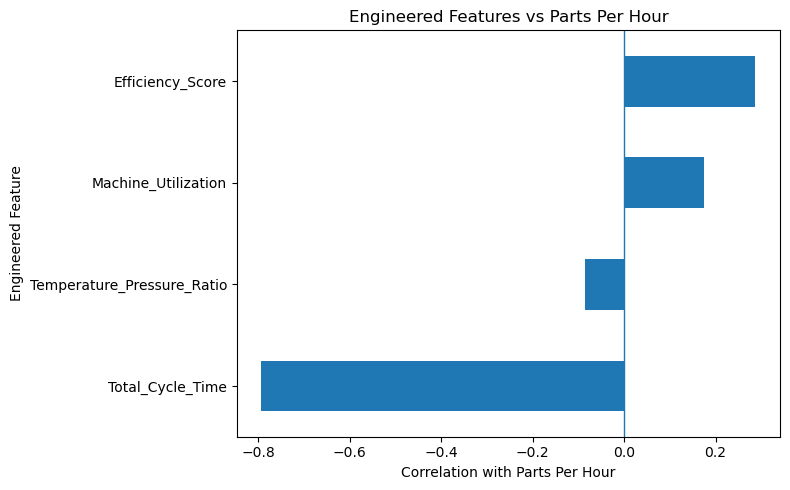

In [41]:
engineered_corr = (
    df[engineered_features + ["Parts_Per_Hour"]]
    .corr()["Parts_Per_Hour"]
    .drop("Parts_Per_Hour")
    .sort_values()
)

plt.figure(figsize=(8, 5))

engineered_corr.plot(kind="barh")

plt.xlabel("Correlation with Parts Per Hour")
plt.ylabel("Engineered Feature")
plt.title("Engineered Features vs Parts Per Hour")

plt.axvline(0, linewidth=1)

plt.tight_layout()
plt.show()